# Task 4 — Algorithmic Trading Strategies


## 0. Imports & Constants

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.optimize import minimize
from statsmodels.tsa.seasonal import STL
import os, warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

SERIES        = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']
SENTINEL_DAYS = {2836, 3430, 4118}  # single-day synced gaps within the analysis window
DATA_START    = 1500                # days 1-1499 have per-series multi-day gaps → excluded
RF_ANNUAL     = 0.03        # 3 % annual risk-free rate
TRADING_DAYS  = 365         # calendar-day annualisation (data includes weekends)
IS_WINDOW     = 500         # in-sample calibration window per fold
OOS_STEP      = 100         # OOS block size and walk-forward slide step
N_BOOT        = 2000        # bootstrap resamples for significance testing

os.makedirs('../Output/task4', exist_ok=True)
rf_daily = RF_ANNUAL / TRADING_DAYS   # simple daily rf used for flat-slot earnings
print(f'rf_daily = {rf_daily:.6f}  |  IS={IS_WINDOW} days  |  OOS_STEP={OOS_STEP} days')


rf_daily = 0.000082  |  IS=500 days  |  OOS_STEP=100 days


## 1. Data Loading

Days 1–1499 are excluded. Each series has independent multi-day gaps in that period — one asset might be missing days 200–250 while another is missing days 400–450. After `dropna(how='any')`, only rows where all seven series simultaneously have data survive, which produces a sparse and temporally misaligned sample. Rolling windows computed on it span unpredictable real-time lengths and covariance estimates are biased.

From day 1500 onwards all seven series are continuously observed. Three single-day gaps remain (days 2836, 3430, 4118) but these hit all series on the same day, so `dropna` removes them symmetrically — cross-series timing is preserved and only six rows are lost.

The last **20 %** of the clean window is reserved as a true held-out OoS period and is never touched during strategy development or parameter tuning.


In [25]:
prices_full = (pd.read_csv('../Data/spiff_data-2.csv', index_col='day')
               .drop(columns=['Unnamed: 0'], errors='ignore'))
prices_full.loc[prices_full.index.isin(SENTINEL_DAYS)] = np.nan

# Crop to gap-free window; dropna removes the 3 synced single-day gaps + their successors
prices_obs   = prices_full.loc[DATA_START:5256, SERIES].copy()
prices_clean = prices_obs.dropna(how='any')

# Log returns — diff propagates NaN to the successor day; dropna removes both
log_returns = np.log(prices_obs).diff().dropna(how='any')

# ── True OoS holdout: last 20 % — never touched until Section 8 ──────────────
n_clean        = len(prices_clean)
HOLDOUT_N      = int(n_clean * 0.20)
prices_pseudo  = prices_clean.iloc[:-HOLDOUT_N]
prices_holdout = prices_clean.iloc[-HOLDOUT_N:]
lr_pseudo      = log_returns.loc[log_returns.index.isin(prices_pseudo.index)]
lr_holdout     = log_returns.loc[log_returns.index.isin(prices_holdout.index)]

print(f'Clean prices  : {n_clean} rows  (days {prices_clean.index[0]}–{prices_clean.index[-1]})')
print(f'Dev pool      : {len(prices_pseudo)} rows  (walk-forward calibration + pseudo-OoS)')
print(f'True holdout  : {len(prices_holdout)} rows  [LOCKED until Section 8]')
print(f'Log-ret rows  : {len(log_returns)}')
print(f'Expected folds: ~{(len(lr_pseudo) - IS_WINDOW) // OOS_STEP}')


Clean prices  : 4901 rows  (days 1–5256)
Dev pool      : 3921 rows  (walk-forward calibration + pseudo-OoS)
True holdout  : 980 rows  [LOCKED until Section 8]
Log-ret rows  : 4888
Expected folds: ~34


## 2. Performance Framework

All strategies are evaluated using the same set of metrics.

### Sharpe ratio

$$\text{SR} = \frac{\overline{r}\cdot 365 - R_F}{\sigma_r \cdot \sqrt{365}}$$

$\overline{r}$ and $\sigma_r$ are the **daily** mean and standard deviation of strategy returns; $R_F = 0.03$ is the annual risk-free rate. When a strategy is flat (out of the market) it earns `rf_daily = RF / 365` per day.

`backtest_metrics` also reports annualised volatility, Sortino ratio, Calmar ratio, and maximum drawdown. `run_walk_forward` slices the development data into IS/OOS folds and concatenates the OOS blocks — no IS returns are included in performance figures.


In [26]:
# ── Core metrics ─────────────────────────────────────────────────────────────

def sharpe(daily_rets, ann=TRADING_DAYS, rf=RF_ANNUAL):
    """Annualised Sharpe ratio.  Returns 0.0 when std ≈ 0."""
    std = daily_rets.std()
    return 0.0 if std < 1e-10 else (daily_rets.mean() * ann - rf) / (std * np.sqrt(ann))

def max_drawdown(daily_rets):
    cum  = (1 + daily_rets).cumprod()
    peak = cum.cummax()
    return ((cum - peak) / peak).min()

def backtest_metrics(daily_rets, label=''):
    """Full metrics dict for a daily return series."""
    r        = daily_rets.dropna()
    ann_ret  = r.mean() * TRADING_DAYS
    ann_vol  = r.std()  * np.sqrt(TRADING_DAYS)
    sh       = sharpe(r)
    mdd      = max_drawdown(r)
    neg      = r[r < 0]
    dvol     = neg.std() * np.sqrt(TRADING_DAYS) if len(neg) > 1 else np.nan
    sortino  = ann_ret / dvol if dvol and dvol > 0 else np.nan
    calmar   = ann_ret / abs(mdd) if mdd < 0 else np.nan
    if label:
        print(f'{label:<32s}  Return={ann_ret:+.2%}  Vol={ann_vol:.2%}  '
              f'Sharpe={sh:.3f}  Sortino={sortino:.3f}  MaxDD={mdd:.2%}')
    return {'Strategy': label, 'Ann. Return': ann_ret, 'Ann. Vol': ann_vol,
            'Sharpe': sh, 'Sortino': sortino, 'Calmar': calmar, 'Max Drawdown': mdd}

# ── Walk-forward engine ───────────────────────────────────────────────────────

def run_walk_forward(fold_fn, ret_df, prices_df):
    """
    Sliding walk-forward.
    fold_fn(ret_is, ret_oos, prices_window) → pd.Series of OOS portfolio log-returns.
    prices_window spans IS-start through OOS-end so stateful signals initialise correctly.
    """
    n = len(ret_df)
    oos_chunks, fold_sharpes = [], []
    pos = IS_WINDOW
    while pos + OOS_STEP <= n:
        ret_is   = ret_df.iloc[pos - IS_WINDOW : pos]
        ret_oos  = ret_df.iloc[pos : pos + OOS_STEP]
        prices_w = prices_df.loc[ret_is.index[0] : ret_oos.index[-1]]
        oos      = fold_fn(ret_is, ret_oos, prices_w)
        oos_chunks.append(oos)
        fold_sharpes.append(sharpe(oos))
        pos += OOS_STEP
    return pd.concat(oos_chunks), fold_sharpes

def fold_stats(fold_sharpes, label=''):
    arr = np.array(fold_sharpes)
    pct = np.mean(arr > 0) * 100
    if label:
        print(f'{label:<30s}  mean={arr.mean():.3f}  std={arr.std():.3f}  '
              f'min={arr.min():.3f}  max={arr.max():.3f}  pos={pct:.0f}%')
    return {'Strategy': label, 'Mean Fold SR': arr.mean(), 'Std Fold SR': arr.std(),
            'Min': arr.min(), 'Max': arr.max(), '% Pos Folds': pct}


## 3. Strategy Definitions

### 3.1 Buy & Hold (benchmark)

Holds an equal 1/7 weight in each of the seven assets for the entire OOS window. No parameters, no signals — serves as the passive baseline every active strategy must beat.


In [27]:
def bh_fold(ret_is, ret_oos, prices_w):
    return ret_oos[SERIES].mean(axis=1)


### 3.2 Moving Average Crossover

Goes long an asset when its fast moving average was above its slow moving average yesterday; otherwise stays flat and earns the risk-free rate. The fast and slow window lengths are chosen independently per asset each fold by maximising IS Sharpe over a grid.


In [28]:
F_GRID = [10, 20, 30]
S_GRID = [40, 60, 90, 120]

def ma_signals(prices_s, fast, slow):
    """1=long, 0=flat. Uses yesterday's MAs — no lookahead."""
    return (prices_s.rolling(fast).mean().shift(1) >
            prices_s.rolling(slow).mean().shift(1)).astype(float)

def ma_fold(ret_is, ret_oos, prices_w):
    prices_is = prices_w.loc[:ret_is.index[-1]]
    best_f, best_s = {}, {}
    for col in SERIES:
        best_sh = -np.inf
        for f in F_GRID:
            for s in S_GRID:
                if f >= s: continue
                sig = ma_signals(prices_is[col], f, s).reindex(ret_is.index).fillna(0)
                sh  = sharpe(sig * ret_is[col] + (1 - sig) * rf_daily)
                if sh > best_sh:
                    best_sh, best_f[col], best_s[col] = sh, f, s
    n    = len(SERIES)
    port = pd.Series(0.0, index=ret_oos.index)
    for col in SERIES:
        # Compute signal on full prices_w so warm-up is correct at OOS boundary
        sig  = ma_signals(prices_w[col], best_f[col], best_s[col]).reindex(ret_oos.index).fillna(0)
        port += (1/n) * (sig * ret_oos[col] + (1 - sig) * rf_daily)
    return port


### 3.3 Channel Breakout (Donchian)

Enters long when today's price exceeds the N-day prior high (breakout entry); exits when price falls below the M-day prior low (trailing stop). The signal is stateful — the position held at the end of the IS window carries directly into the first OOS day, so there is no cold-start artefact at the fold boundary.


In [29]:
N_GRID = [20, 40, 60]
M_GRID = [10, 20, 30]

def donchian_signals(prices_s, N, M):
    highs  = prices_s.rolling(N).max().shift(1).values
    lows   = prices_s.rolling(M).min().shift(1).values
    vals   = prices_s.values
    sig    = np.zeros(len(vals))
    in_pos = False
    for i in range(len(vals)):
        p = vals[i]
        if np.isnan(p): in_pos = False; continue
        if in_pos:
            if not np.isnan(lows[i]) and p < lows[i]: in_pos = False
        else:
            if not np.isnan(highs[i]) and p > highs[i]: in_pos = True
        sig[i] = 1.0 if in_pos else 0.0
    return pd.Series(sig, index=prices_s.index)

def donchian_fold(ret_is, ret_oos, prices_w):
    prices_is = prices_w.loc[:ret_is.index[-1]]
    best_N, best_M = {}, {}
    for col in SERIES:
        best_sh = -np.inf
        for N in N_GRID:
            for M in M_GRID:
                sig = donchian_signals(prices_is[col], N, M).shift(1).reindex(ret_is.index).fillna(0)
                sh  = sharpe(sig * ret_is[col] + (1 - sig) * rf_daily)
                if sh > best_sh:
                    best_sh, best_N[col], best_M[col] = sh, N, M
    n    = len(SERIES)
    port = pd.Series(0.0, index=ret_oos.index)
    for col in SERIES:
        sig_oos = (donchian_signals(prices_w[col], best_N[col], best_M[col])
                   .shift(1).reindex(ret_oos.index).fillna(0))
        port += (1/n) * (sig_oos * ret_oos[col] + (1 - sig_oos) * rf_daily)
    return port


### 3.4 Buy the Dip

Enters long after a sharp short-term decline: when the k-day cumulative return falls below −X the strategy goes long and holds for exactly H days regardless of subsequent price moves. Like the Donchian strategy, the hold counter is carried across the IS/OOS boundary so partial holds are not lost.


In [30]:
K_GRID = [3, 5, 10]
X_GRID = [0.02, 0.03, 0.05]
H_GRID = [5, 10, 20]

def dip_signals(ret_s, k, X, H):
    cum_k = ret_s.rolling(k).sum().values
    sig   = np.zeros(len(ret_s))
    hold  = 0
    for i in range(len(ret_s)):
        if hold > 0:
            sig[i] = 1.0; hold -= 1
        elif not np.isnan(cum_k[i]) and cum_k[i] < -X:
            sig[i] = 1.0; hold = H - 1
    return pd.Series(sig, index=ret_s.index)

def dip_fold(ret_is, ret_oos, prices_w):
    best_k, best_X, best_H = {}, {}, {}
    for col in SERIES:
        best_sh = -np.inf
        for k in K_GRID:
            for X in X_GRID:
                for H in H_GRID:
                    sig = dip_signals(ret_is[col], k, X, H).shift(1).fillna(0)
                    sh  = sharpe(sig * ret_is[col] + (1 - sig) * rf_daily)
                    if sh > best_sh:
                        best_sh, best_k[col], best_X[col], best_H[col] = sh, k, X, H
    n            = len(SERIES)
    port         = pd.Series(0.0, index=ret_oos.index)
    ret_combined = pd.concat([ret_is, ret_oos])
    for col in SERIES:
        sig_oos = (dip_signals(ret_combined[col], best_k[col], best_X[col], best_H[col])
                   .shift(1).reindex(ret_oos.index).fillna(0))
        port += (1/n) * (sig_oos * ret_oos[col] + (1 - sig_oos) * rf_daily)
    return port


### 3.5 Pairs Trading — OLS Hedge Ratio, Long-Short

Trades the mean-reverting spread between two correlated pairs identified in Task 1: **(gurkor, water)** and **(guitars, slingshots)**. Each fold estimates a hedge ratio β via OLS on IS log prices, then standardises the spread using its IS mean and standard deviation.

Positions are long-short: +1 buys asset A and shorts asset B when the spread is unusually low; −1 reverses when the spread is unusually high; 0 when the spread is within the exit band.

> Task 1 found no long-run cointegration between any pair, so the strategy relies on short-term reversion of the spread within each IS window rather than a guaranteed equilibrium.


In [31]:
PAIRS     = [('gurkor', 'water'), ('guitars', 'slingshots')]
Z_EXIT    = 0.5
Z_GRID_P  = [1.0, 1.5, 2.0, 2.5]

def pairs_ls_signals(log_pA, log_pB, beta, mu_s, sigma_s, z_entry):
    """
    Long-short state machine.
    +1 = long A / short B (spread below −z_entry σ)
    −1 = short A / long B (spread above +z_entry σ)
     0 = flat (|z| < Z_EXIT)
    """
    spread = (log_pA - beta * log_pB).values
    z      = (spread - mu_s) / sigma_s
    sig    = np.zeros(len(z))
    state  = 0
    for i in range(len(z)):
        if state ==  0:
            if   z[i] < -z_entry: state =  1
            elif z[i] >  z_entry: state = -1
        elif state ==  1:
            if   z[i] > -Z_EXIT:  state =  0
        elif state == -1:
            if   z[i] <  Z_EXIT:  state =  0
        sig[i] = state
    return pd.Series(sig, index=log_pA.index)

def pairs_fold(ret_is, ret_oos, prices_w):
    log_w  = np.log(prices_w)
    log_is = log_w.loc[:ret_is.index[-1]]
    n_p    = len(PAIRS)
    port   = pd.Series(0.0, index=ret_oos.index)

    for (A, B) in PAIRS:
        X     = np.column_stack([np.ones(len(log_is)), log_is[B].values])
        beta  = np.linalg.lstsq(X, log_is[A].values, rcond=None)[0][1]
        s_is  = log_is[A] - beta * log_is[B]
        mu_s, sigma_s = s_is.mean(), s_is.std()
        if sigma_s < 1e-8: continue

        # Tune z_entry on IS Sharpe
        best_sh, best_z = -np.inf, Z_GRID_P[0]
        for z_e in Z_GRID_P:
            sig_is = (pairs_ls_signals(log_is[A], log_is[B], beta, mu_s, sigma_s, z_e)
                      .shift(1).reindex(ret_is.index).fillna(0))
            norm  = 1 + abs(beta)
            pr    = sig_is * (ret_is[A] - beta * ret_is[B]) / norm + (1 - sig_is.abs()) * rf_daily
            if sharpe(pr) > best_sh:
                best_sh, best_z = sharpe(pr), z_e

        # OOS — signal on IS+OOS prices so state carries over
        sig_oos  = (pairs_ls_signals(log_w[A], log_w[B], beta, mu_s, sigma_s, best_z)
                    .shift(1).reindex(ret_oos.index).fillna(0))
        norm     = 1 + abs(beta)
        pair_ret = sig_oos * (ret_oos[A] - beta * ret_oos[B]) / norm + (1 - sig_oos.abs()) * rf_daily
        port    += pair_ret / n_p

    return port


### 3.6 Time-Series Momentum with Volatility Scaling (TSMOM)

Three findings from Task 1 motivate this strategy:

- **Positive lag-1 autocorrelation** in most return series → a recent trend is likely to continue (momentum signal)
- **Significant ARCH effects** → realised volatility is forecastable, so scaling positions inversely to recent vol improves risk-adjusted returns
- **Two-tier volatility structure** (gurkor/water ~6 % p.a. vs the other five ~20–24 %) → without vol scaling, equal-weight allocation would be dominated by the high-vol assets

Position size: $\text{pos}_t = \text{sign}(R_{t-N:t-1}) \times \dfrac{\sigma^*}{\hat{\sigma}_{t-1}}$, capped at ±3×, where $\sigma^* = 1\%$ daily is the vol target. The strategy is always invested (long or short) so there is no flat-slot rf adjustment.

*Reference: Moskowitz, Ooi & Pedersen (2012) "Time series momentum."*


In [32]:
TARGET_VOL  = 0.01     # 1 % daily vol target per asset (~16 % ann)
VOL_WINDOW  = 60       # realised vol estimation window
MAX_LEV     = 3.0      # per-asset leverage cap
N_GRID_TSM  = [20, 60, 120, 252]

def tsmom_signals(ret_s, N):
    cum_ret = ret_s.rolling(N).sum().shift(1)
    sigma   = ret_s.rolling(VOL_WINDOW).std().shift(1).clip(lower=1e-8)
    pos     = np.sign(cum_ret) * (TARGET_VOL / sigma)
    return pos.clip(-MAX_LEV, MAX_LEV).fillna(0)

def tsmom_fold(ret_is, ret_oos, prices_w):
    best_N = {}
    for col in SERIES:
        best_sh = -np.inf
        for N in N_GRID_TSM:
            pos = tsmom_signals(ret_is[col], N)
            sh  = sharpe(pos * ret_is[col])
            if sh > best_sh:
                best_sh, best_N[col] = sh, N

    ret_combined = pd.concat([ret_is, ret_oos])
    n    = len(SERIES)
    port = pd.Series(0.0, index=ret_oos.index)
    for col in SERIES:
        pos_oos = tsmom_signals(ret_combined[col], best_N[col]).reindex(ret_oos.index).fillna(0)
        port   += (1/n) * pos_oos * ret_oos[col]
    return port


### 3.7 Seasonal Cycle (STL decomposition)

Task 1 identified a ~310–390-day seasonal cycle in all seven price series. Each fold fits an STL decomposition to IS log prices and selects the period (from a small grid) that maximises the seasonal-to-residual variance ratio. The seasonal component is then tiled forward into the OOS window.

Signal: long when the seasonal component is rising (a tailwind), flat (earning rf) when it is falling. Because the seasonal period is roughly a year, the signal changes direction only ~twice per year, keeping turnover near zero.


In [33]:
SEASON_PERIOD_GRID = [290, 320, 350, 380]

def seasonal_fold(ret_is, ret_oos, prices_w):
    prices_is = prices_w.loc[:ret_is.index[-1]]
    n_oos = len(ret_oos)
    n     = len(SERIES)
    port  = pd.Series(0.0, index=ret_oos.index)

    for col in SERIES:
        log_p_is = np.log(prices_is[col].dropna())

        best_vr, best_period = -np.inf, SEASON_PERIOD_GRID[0]
        for period in SEASON_PERIOD_GRID:
            if len(log_p_is) < period + 50: continue
            try:
                res = STL(log_p_is, period=period, robust=True).fit()
                vr  = res.seasonal.var() / (res.resid.var() + 1e-12)
                if vr > best_vr: best_vr, best_period = vr, period
            except Exception:
                pass

        if best_vr == -np.inf:
            port += (1/n) * rf_daily; continue

        res_best   = STL(log_p_is, period=best_period, robust=True).fit()
        seas_is    = res_best.seasonal.values
        last_cycle = seas_is[-best_period:]
        extra      = np.tile(last_cycle, (n_oos // best_period) + 2)[:n_oos]
        seas_ext   = np.concatenate([seas_is, extra])
        n_is       = len(seas_is)
        slope      = np.diff(seas_ext, append=seas_ext[-1])
        sig_arr    = (slope[n_is - 1 : n_is + n_oos - 1] > 0).astype(float)
        sig_oos    = pd.Series(sig_arr, index=ret_oos.index)
        port      += (1/n) * (sig_oos * ret_oos[col] + (1 - sig_oos) * rf_daily)

    return port


### 3.8 Minimum Variance Portfolio (MVP)

The seven assets span two very different volatility regimes: gurkor and water at ~6 % p.a. and the remaining five at ~20–24 % p.a. An equal-weight allocation puts 1/7 of capital in each asset but lets the high-vol group dominate portfolio risk.

MVP solves $\min_w\; w^\top \Sigma w$ subject to $\sum w_i = 1$ and $w_i \geq 0$, using the IS covariance matrix estimated each fold. No expected-return forecast is needed — only the covariance structure.


In [34]:
def mvp_weights(cov_matrix):
    n   = len(cov_matrix)
    res = minimize(lambda w: w @ cov_matrix @ w,
                   x0=np.ones(n)/n,
                   method='SLSQP',
                   bounds=[(0.0, 1.0)]*n,
                   constraints={'type':'eq','fun': lambda w: w.sum()-1},
                   options={'ftol':1e-12,'maxiter':1000})
    return res.x if res.success else np.ones(n)/n

def mvp_fold(ret_is, ret_oos, prices_w):
    cov = ret_is[SERIES].cov().values
    w   = mvp_weights(cov)
    return pd.Series(ret_oos[SERIES].values @ w, index=ret_oos.index)


## 4. Pseudo-OoS Walk-Forward Results

Each strategy is evaluated by sliding a 500-day IS window and 100-day OOS window across the development pool. Parameters are re-estimated from scratch at each fold using only IS data. The OOS blocks are concatenated to form a single return series per strategy — these are the numbers reported here.


In [35]:
STRATS = [
    ('Buy & Hold',   bh_fold),
    ('MA Crossover', ma_fold),
    ('Ch. Breakout', donchian_fold),
    ('Buy the Dip',  dip_fold),
    ('Pairs (L/S)',  pairs_fold),
    ('TSMOM',        tsmom_fold),
    ('Seasonal',     seasonal_fold),
    ('MVP',          mvp_fold),
]

print('Running walk-forward (~2–3 min)...')
WF = {}
for name, fn in STRATS:
    wf_rets, fold_srs = run_walk_forward(fn, lr_pseudo, prices_pseudo)
    WF[name] = {'rets': wf_rets, 'fold_srs': fold_srs}
    print(f'  ✓ {name}')
print('Done.')


Running walk-forward (~2–3 min)...
  ✓ Buy & Hold
  ✓ MA Crossover
  ✓ Ch. Breakout
  ✓ Buy the Dip
  ✓ Pairs (L/S)
  ✓ TSMOM
  ✓ Seasonal
  ✓ MVP
Done.


In [36]:
print('=== Walk-Forward Portfolio Performance ===')
metric_rows, fold_rows = [], []
for name, _ in STRATS:
    metric_rows.append(backtest_metrics(WF[name]['rets'], label=name))
    fold_rows.append(fold_stats(WF[name]['fold_srs'], label=name))

perf_tbl = pd.DataFrame(metric_rows).set_index('Strategy').round(4)
perf_tbl['Ann. Return']  = perf_tbl['Ann. Return'].map('{:+.2%}'.format)
perf_tbl['Ann. Vol']     = perf_tbl['Ann. Vol'].map('{:.2%}'.format)
perf_tbl['Max Drawdown'] = perf_tbl['Max Drawdown'].map('{:.2%}'.format)
perf_tbl['Sharpe']       = perf_tbl['Sharpe'].map('{:.3f}'.format)
perf_tbl['Sortino']      = perf_tbl['Sortino'].map('{:.3f}'.format)
perf_tbl['Calmar']       = perf_tbl['Calmar'].map('{:.3f}'.format)
display(perf_tbl)

fold_tbl = pd.DataFrame(fold_rows).set_index('Strategy').round(3)
print()
display(fold_tbl)


=== Walk-Forward Portfolio Performance ===
Buy & Hold                        Return=+1.97%  Vol=11.11%  Sharpe=-0.092  Sortino=0.250  MaxDD=-37.55%
Buy & Hold                      mean=0.187  std=2.326  min=-4.637  max=5.681  pos=44%
MA Crossover                      Return=+4.99%  Vol=6.45%  Sharpe=0.309  Sortino=1.041  MaxDD=-15.02%
MA Crossover                    mean=0.189  std=2.134  min=-3.307  max=5.039  pos=50%
Ch. Breakout                      Return=+2.69%  Vol=5.53%  Sharpe=-0.056  Sortino=0.629  MaxDD=-12.79%
Ch. Breakout                    mean=-0.169  std=1.805  min=-4.458  max=3.692  pos=41%
Buy the Dip                       Return=+3.83%  Vol=7.05%  Sharpe=0.118  Sortino=0.601  MaxDD=-17.00%
Buy the Dip                     mean=0.463  std=1.673  min=-2.182  max=5.056  pos=47%
Pairs (L/S)                       Return=+0.27%  Vol=6.26%  Sharpe=-0.436  Sortino=0.056  MaxDD=-9.59%
Pairs (L/S)                     mean=-0.470  std=1.524  min=-3.595  max=2.188  pos=38%
TSMOM  

,Ann. Return,Ann. Vol,Sharpe,Sortino,Calmar,Max Drawdown
Strategy,,,,,,
Buy & Hold,+1.97%,11.11%,-0.092,0.250,0.053,-37.55%
MA Crossover,+4.99%,6.45%,0.309,1.041,0.332,-15.02%
Ch. Breakout,+2.69%,5.53%,-0.056,0.629,0.210,-12.79%
Buy the Dip,+3.83%,7.05%,0.118,0.601,0.225,-17.00%
Pairs (L/S),+0.27%,6.26%,-0.436,0.056,0.028,-9.59%
TSMOM,+6.23%,8.32%,0.388,1.108,0.493,-12.63%
Seasonal,+2.93%,7.58%,-0.009,0.500,0.125,-23.41%
MVP,+3.87%,5.05%,0.172,1.105,0.505,-7.65%


,Mean Fold SR,Std Fold SR,Min,Max,% Pos Folds
Strategy,,,,,
Buy & Hold,0.187,2.326,-4.637,5.681,44.118
MA Crossover,0.189,2.134,-3.307,5.039,50.000
Ch. Breakout,-0.169,1.805,-4.458,3.692,41.176
Buy the Dip,0.463,1.673,-2.182,5.056,47.059
Pairs (L/S),-0.470,1.524,-3.595,2.188,38.235
TSMOM,0.339,2.213,-4.371,5.078,61.765
Seasonal,0.258,2.175,-5.169,5.062,47.059
MVP,0.314,1.965,-4.478,4.390,50.000


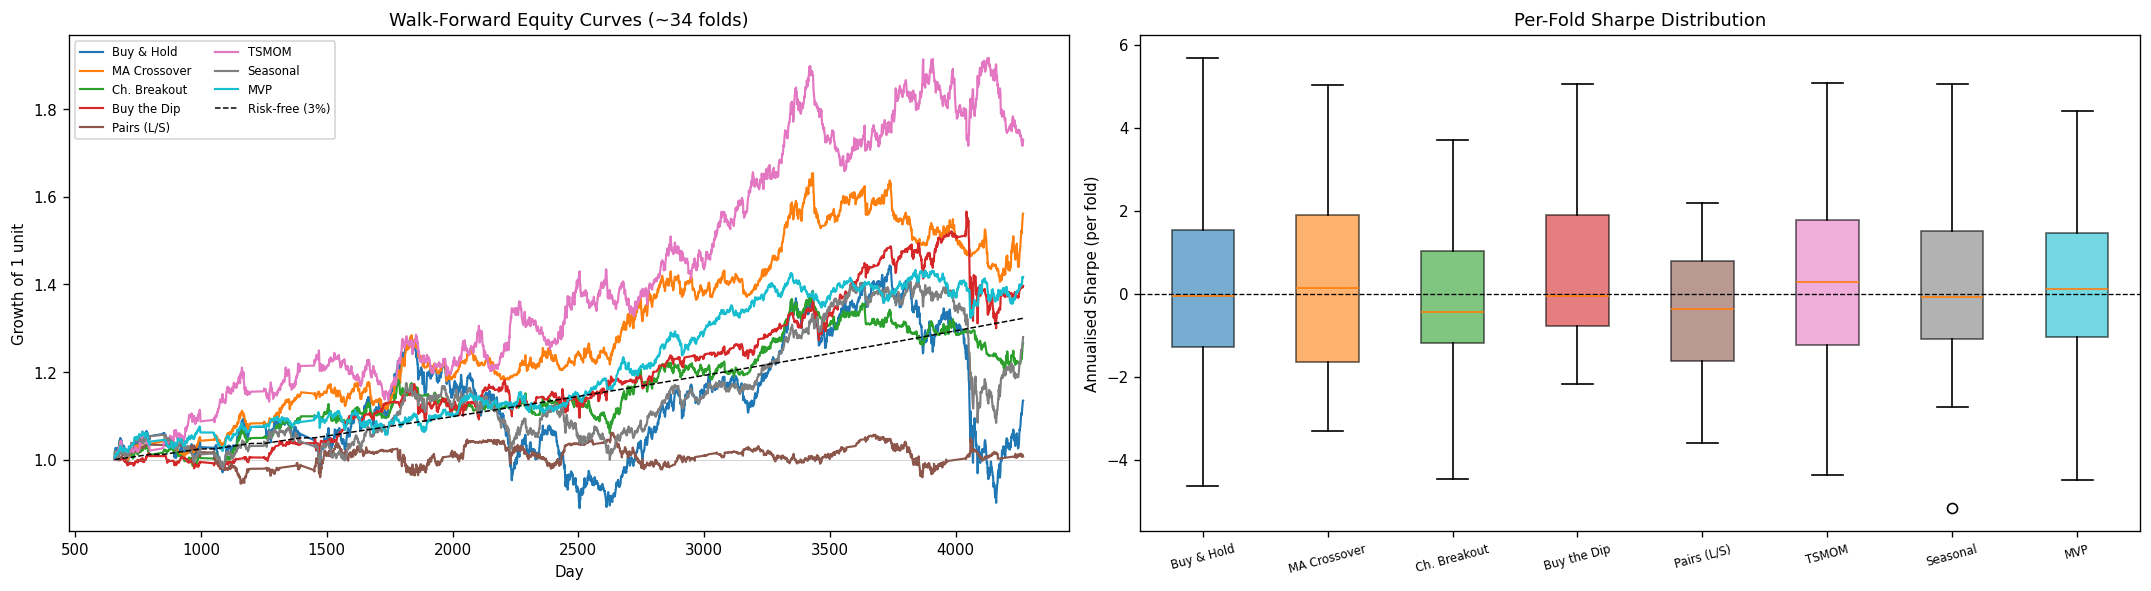

In [37]:
COLORS = dict(zip([n for n,_ in STRATS], plt.cm.tab10(np.linspace(0, 0.9, len(STRATS)))))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

ax = axes[0]
for name, _ in STRATS:
    cum = (1 + WF[name]['rets']).cumprod()
    ax.plot(cum.index, cum.values, lw=1.3, label=name, color=COLORS[name])
n_oos   = len(WF['Buy & Hold']['rets'])
rf_curve = (1 + rf_daily) ** np.arange(1, n_oos + 1)
ax.plot(WF['Buy & Hold']['rets'].index, rf_curve, 'k--', lw=0.9, label='Risk-free (3%)')
ax.axhline(1.0, color='gray', lw=0.4, alpha=0.5)
ax.set(xlabel='Day', ylabel='Growth of 1 unit',
       title=f'Walk-Forward Equity Curves (~{len(WF["Buy & Hold"]["fold_srs"])} folds)')
ax.legend(fontsize=7, ncol=2)

ax2 = axes[1]
all_data   = [WF[n]['fold_srs'] for n,_ in STRATS]
all_labels = [n for n,_ in STRATS]
bp = ax2.boxplot(all_data, labels=all_labels, patch_artist=True)
for patch, (name,_) in zip(bp['boxes'], STRATS):
    patch.set_facecolor(COLORS[name]); patch.set_alpha(0.6)
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.set(ylabel='Annualised Sharpe (per fold)', title='Per-Fold Sharpe Distribution')
ax2.tick_params(axis='x', labelsize=7, rotation=15)

plt.tight_layout()
plt.savefig('../Output/task4/equity_curves.png', dpi=150)
plt.show()


## 5. Bootstrap Sharpe Significance

To test whether each strategy's Sharpe ratio is distinguishable from zero, we resample the OOS returns with replacement 2,000 times and record the Sharpe of each resample. The p-value is the fraction of bootstrap samples with Sharpe ≤ 0.

Because we test eight strategies simultaneously, we apply **Benjamini-Hochberg FDR correction** at α = 5 % to control the expected proportion of false discoveries among the rejected tests.

> Resampling with replacement destroys the serial order of returns. For strategies that hold positions over multiple days this understates the true variance of the Sharpe estimator, making p-values optimistically small. The bootstrap result should be read as a lower bound on uncertainty.


In [38]:
def bootstrap_sharpe_pvalue(ret_series, n_boot=N_BOOT, seed=42):
    """Returns (actual_SR, p_value, (CI_lo_5pct, CI_hi_95pct))."""
    rng  = np.random.default_rng(seed)
    vals = ret_series.dropna().values
    if len(vals) < 10 or (vals == 0).all():
        return np.nan, np.nan, (np.nan, np.nan)
    n, boot = len(vals), []
    for _ in range(n_boot):
        s   = rng.choice(vals, size=n, replace=True)
        std = s.std()
        boot.append((s.mean() * TRADING_DAYS - RF_ANNUAL) / (std * np.sqrt(TRADING_DAYS))
                    if std > 1e-10 else np.nan)
    boot   = np.array(boot)
    actual = sharpe(pd.Series(vals))
    lo, hi = np.nanpercentile(boot, [5, 95])
    p_val  = float(np.nanmean(boot <= 0))
    return round(actual, 3), round(p_val, 3), (round(lo, 3), round(hi, 3))

def bh_fdr(p_values, alpha=0.05):
    """Benjamini-Hochberg: returns boolean reject array."""
    p   = np.asarray(p_values, dtype=float)
    n   = len(p)
    idx = np.argsort(p)
    thr = (np.arange(1, n+1) / n) * alpha
    rej = np.zeros(n, dtype=bool)
    below = p[idx] <= thr
    if below.any():
        rej[:np.where(below)[0][-1] + 1] = True
    out = np.zeros(n, dtype=bool)
    out[idx] = rej
    return out

print('Computing bootstrap Sharpe p-values...')
boot_records = []
for name, _ in STRATS:
    sr, pv, (lo, hi) = bootstrap_sharpe_pvalue(WF[name]['rets'])
    boot_records.append({'Strategy': name, 'Sharpe': sr, 'p-value': pv,
                         'CI 5%': lo, 'CI 95%': hi})

boot_df = pd.DataFrame(boot_records).set_index('Strategy')
p_arr   = boot_df['p-value'].values
boot_df['BH reject α=5%'] = bh_fdr(p_arr)
print(boot_df.to_string())


Computing bootstrap Sharpe p-values...
              Sharpe  p-value  CI 5%  CI 95%  BH reject α=5%
Strategy                                                    
Buy & Hold    -0.092    0.622 -0.632   0.439           False
MA Crossover   0.309    0.189 -0.244   0.859           False
Ch. Breakout  -0.056    0.574 -0.594   0.476           False
Buy the Dip    0.118    0.370 -0.412   0.625           False
Pairs (L/S)   -0.436    0.905 -1.006   0.101           False
TSMOM          0.388    0.130 -0.172   0.930           False
Seasonal      -0.009    0.535 -0.529   0.513           False
MVP            0.172    0.298 -0.357   0.709           False


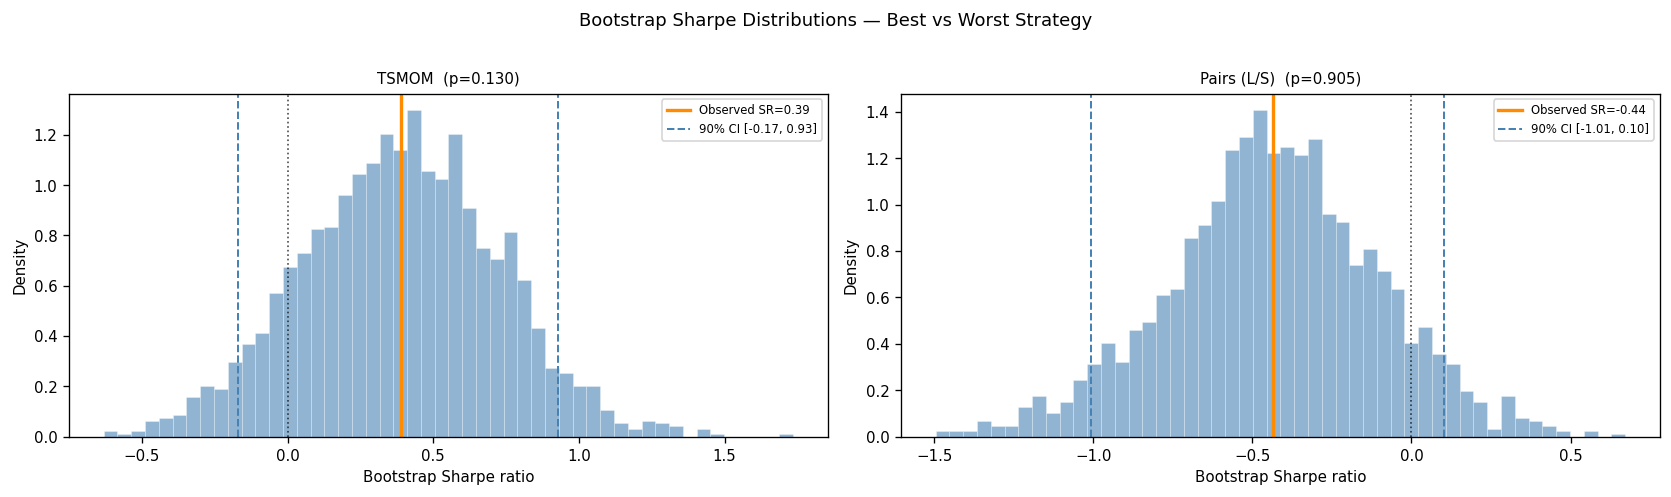

In [39]:
# ── Plot bootstrap distribution for best and worst strategy ──────────────────
def plot_bootstrap_dist(ret_series, label, ax, seed=42):
    rng  = np.random.default_rng(seed)
    vals = ret_series.dropna().values
    n    = len(vals)
    boot = []
    for _ in range(N_BOOT):
        s   = rng.choice(vals, size=n, replace=True)
        std = s.std()
        boot.append((s.mean() * TRADING_DAYS - RF_ANNUAL) / (std * np.sqrt(TRADING_DAYS))
                    if std > 1e-10 else np.nan)
    boot   = np.array(boot)
    actual = sharpe(pd.Series(vals))
    lo, hi = np.nanpercentile(boot, [5, 95])
    pv     = np.nanmean(boot <= 0)
    ax.hist(boot[~np.isnan(boot)], bins=50, density=True,
            color='steelblue', alpha=0.6, edgecolor='white', lw=0.3)
    ax.axvline(actual, color='darkorange', lw=2, label=f'Observed SR={actual:.2f}')
    ax.axvline(0,      color='k',          lw=1, ls=':', alpha=0.7)
    ax.axvline(lo,     color='steelblue',  lw=1.2, ls='--', label=f'90% CI [{lo:.2f}, {hi:.2f}]')
    ax.axvline(hi,     color='steelblue',  lw=1.2, ls='--')
    ax.set_title(f'{label}  (p={pv:.3f})', fontsize=9)
    ax.legend(fontsize=7)

best_strat  = boot_df['Sharpe'].idxmax()
worst_strat = boot_df['Sharpe'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_bootstrap_dist(WF[best_strat]['rets'],  best_strat,  axes[0])
plot_bootstrap_dist(WF[worst_strat]['rets'], worst_strat, axes[1])
for ax in axes:
    ax.set(xlabel='Bootstrap Sharpe ratio', ylabel='Density')
plt.suptitle('Bootstrap Sharpe Distributions — Best vs Worst Strategy', y=1.02)
plt.tight_layout()
plt.savefig('../Output/task4/bootstrap_sharpe.png', dpi=150)
plt.show()


## 6. Parameter Stability

A well-behaved strategy should select similar parameters in each fold — consistent choices indicate the signal is stable across market regimes. Erratic parameter selection across folds is a sign that the IS grid search is fitting noise.

We track the IS-optimal fast and slow MA window for each asset across all folds.


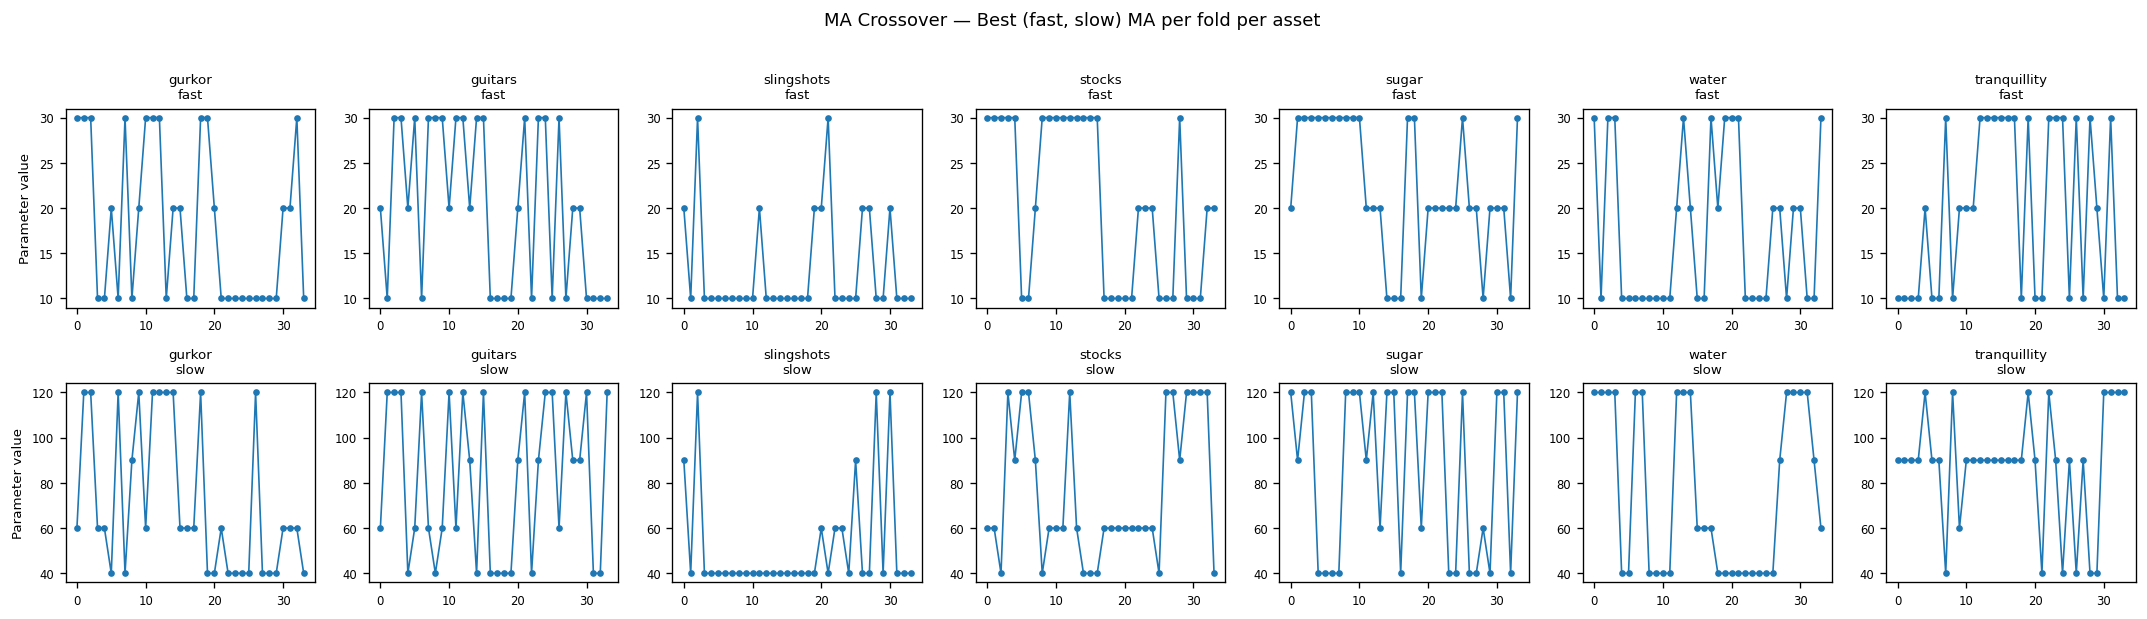


Parameter value frequencies (fast MA):


,gurkor_fast,guitars_fast,slingshots_fast,stocks_fast,sugar_fast,water_fast,tranquillity_fast
10,0.50,0.38,0.74,0.38,0.18,0.53,0.44
20,0.21,0.21,0.21,0.18,0.41,0.21,0.15
30,0.29,0.41,0.06,0.44,0.41,0.26,0.41


In [40]:
def collect_ma_params(ret_df, prices_df):
    """Re-run IS grid search per fold, returning best (fast, slow) per asset per fold."""
    n = len(ret_df)
    records = []
    pos = IS_WINDOW
    while pos + OOS_STEP <= n:
        ret_is    = ret_df.iloc[pos - IS_WINDOW : pos]
        prices_is = prices_df.loc[ret_is.index[0] : ret_is.index[-1]]
        row = {'fold': pos // OOS_STEP - IS_WINDOW // OOS_STEP}
        for col in SERIES:
            best_sh = -np.inf
            for f in F_GRID:
                for s in S_GRID:
                    if f >= s: continue
                    sig = ma_signals(prices_is[col], f, s).reindex(ret_is.index).fillna(0)
                    sh  = sharpe(sig * ret_is[col] + (1 - sig) * rf_daily)
                    if sh > best_sh:
                        best_sh, row[f'{col}_fast'], row[f'{col}_slow'] = sh, f, s
        records.append(row)
        pos += OOS_STEP
    return pd.DataFrame(records).set_index('fold')

print('Collecting MA parameter stability (grid search per fold, ~30 s)...')
ma_params = collect_ma_params(lr_pseudo, prices_pseudo)

fig, axes = plt.subplots(2, len(SERIES), figsize=(18, 5), sharex=False)
for i, col in enumerate(SERIES):
    for ax, param, label in [(axes[0,i], f'{col}_fast', 'fast'),
                              (axes[1,i], f'{col}_slow', 'slow')]:
        vals = ma_params[param]
        ax.plot(vals.index, vals.values, marker='o', ms=3, lw=1)
        ax.set_title(f'{col}\n{label}', fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0: ax.set_ylabel('Parameter value', fontsize=8)

plt.suptitle('MA Crossover — Best (fast, slow) MA per fold per asset', y=1.02)
plt.tight_layout()
plt.savefig('../Output/task4/param_stability_ma.png', dpi=150)
plt.show()

print('\nParameter value frequencies (fast MA):')
display(ma_params[[f'{col}_fast' for col in SERIES]].apply(
    lambda x: x.value_counts(normalize=True).round(2), axis=0).fillna(0))


## 7. Portfolio Optimization — Efficient Frontier

The walk-forward strategies in Section 3 treat portfolio construction and signal generation as separate concerns: each strategy allocates equally across assets and uses a signal to decide *when* to be invested. Here we drop the timing signal entirely and ask what the risk/return structure of the asset universe implies on its own — independent of any entry or exit rule.

We compute two reference portfolios on the IS log-return estimates:

- **MVP** (Minimum Variance Portfolio): the long-only portfolio with the lowest possible variance.   Requires only a covariance estimate; no return forecast.
- **MSR** (Maximum Sharpe Ratio portfolio): the portfolio on the efficient frontier with the highest Sharpe ratio.   Requires both return and covariance estimates and is more sensitive to estimation error in the mean.

The efficient frontier is traced by Monte-Carlo sampling from the feasible weight space.

In [41]:
from scipy.optimize import minimize as _min

log_ret_is = np.log(prices_pseudo).diff().dropna()
mu_a    = log_ret_is.mean() * TRADING_DAYS
Sigma_a = log_ret_is.cov()  * TRADING_DAYS
assets  = list(mu_a.index)
n_a     = len(assets)

def port_vol(w): return float(np.sqrt(w @ Sigma_a.values @ w))
def port_ret(w): return float(w @ mu_a.values)
def neg_sr(w):
    v = port_vol(w)
    return -(port_ret(w) - RF_ANNUAL) / v if v > 1e-10 else 0.0

bounds = [(0., 1.)] * n_a
con    = {'type': 'eq', 'fun': lambda w: w.sum() - 1}
w0     = np.ones(n_a) / n_a

mvp_res = _min(port_vol, w0, method='SLSQP', bounds=bounds, constraints=[con])
msr_res = _min(neg_sr,   w0, method='SLSQP', bounds=bounds, constraints=[con])
mvp_w, msr_w = mvp_res.x, msr_res.x

print('MVP weights:'); print(pd.Series(mvp_w, index=assets).round(3))
print(f'  Vol={port_vol(mvp_w):.4f}  Ret={port_ret(mvp_w):.4f}  SR={(port_ret(mvp_w)-RF_ANNUAL)/port_vol(mvp_w):.3f}')
print()
print('MSR weights:'); print(pd.Series(msr_w, index=assets).round(3))
print(f'  Vol={port_vol(msr_w):.4f}  Ret={port_ret(msr_w):.4f}  SR={(port_ret(msr_w)-RF_ANNUAL)/port_vol(msr_w):.3f}')


MVP weights:
gurkor          0.286
guitars         0.029
slingshots      0.041
stocks          0.041
sugar           0.030
water           0.521
tranquillity    0.052
dtype: float64
  Vol=0.0525  Ret=0.0433  SR=0.254

MSR weights:
gurkor          0.415
guitars         0.064
slingshots      0.022
stocks          0.000
sugar           0.000
water           0.452
tranquillity    0.047
dtype: float64
  Vol=0.0561  Ret=0.0524  SR=0.399


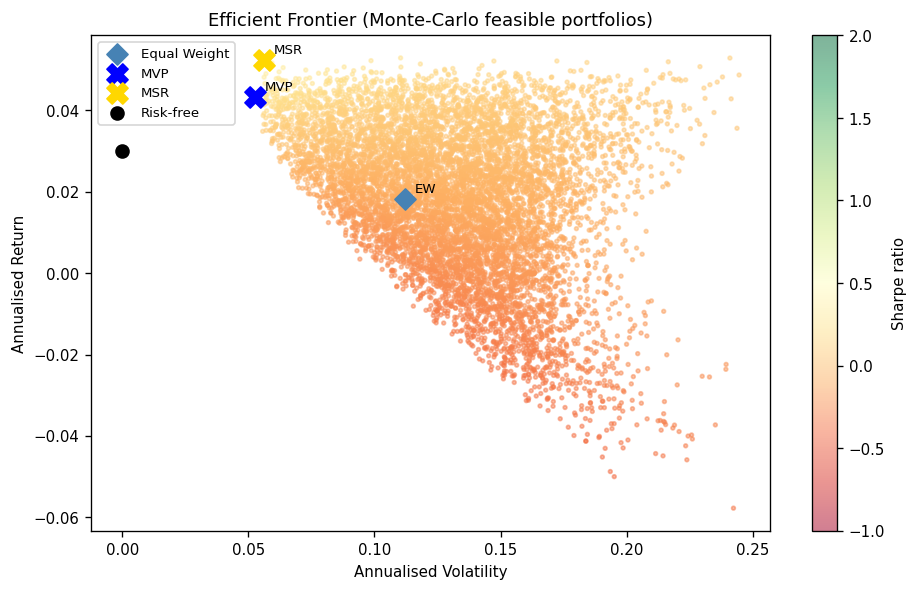

In [ ]:
# ── Efficient frontier by Monte Carlo sampling ────────────────────────────────
N_MC   = 8_000
rng_mc = np.random.default_rng(0)
mc_vols, mc_rets = [], []
for _ in range(N_MC):
    w_raw = rng_mc.dirichlet(np.ones(n_a))
    mc_vols.append(port_vol(w_raw))
    mc_rets.append(port_ret(w_raw))

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(mc_vols, mc_rets, c=[(r - RF_ANNUAL) / v if v > 0 else 0
                                      for r, v in zip(mc_rets, mc_vols)],
                cmap='RdYlGn', s=5, alpha=0.5, vmin=-1, vmax=2)
plt.colorbar(sc, ax=ax, label='Sharpe ratio')

ax.scatter(port_vol(w0),      port_ret(w0),      marker='D', s=80, color='steelblue', zorder=5, label='Equal Weight')
ax.scatter(port_vol(mvp_w),   port_ret(mvp_w),   marker='*', s=160, color='blue',     zorder=5, label='MVP')
ax.scatter(port_vol(msr_w),   port_ret(msr_w),   marker='*', s=160, color='gold',     zorder=5, label='MSR')
ax.scatter([0], [RF_ANNUAL], marker='o', s=60, color='k', zorder=5, label='Risk-free')

for vol, ret, lbl in [(port_vol(w0), port_ret(w0), 'EW'),
                       (port_vol(mvp_w), port_ret(mvp_w), 'MVP'),
                       (port_vol(msr_w), port_ret(msr_w), 'MSR')]:
    ax.annotate(lbl, (vol, ret), textcoords='offset points', xytext=(6,4), fontsize=8)

ax.set(xlabel='Annualised Volatility', ylabel='Annualised Return',
       title='Efficient Frontier (Monte-Carlo feasible portfolios)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../Output/task4/efficient_frontier.png', dpi=150)
plt.show()


Portfolio comparison:
Equal Weight                      Return=+1.97%  Vol=11.11%  Sharpe=-0.092  Sortino=0.250  MaxDD=-37.55%
MVP (WF)                          Return=+3.87%  Vol=5.05%  Sharpe=0.172  Sortino=1.105  MaxDD=-7.65%
MSR (WF)                          Return=+4.99%  Vol=11.75%  Sharpe=0.169  Sortino=0.556  MaxDD=-30.96%


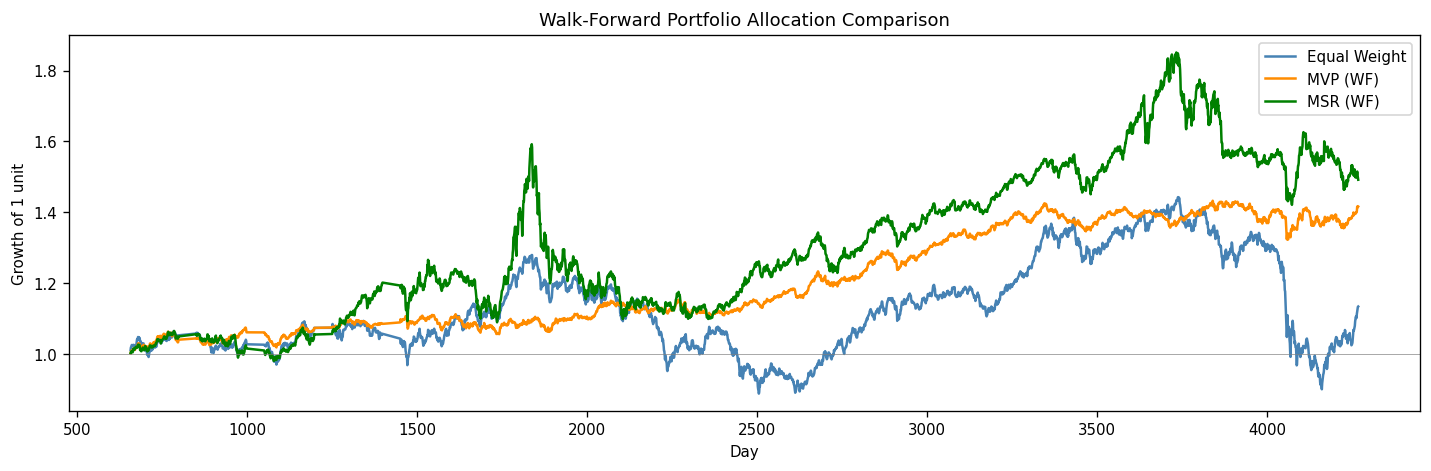

In [43]:
# ── Walk-forward MVP vs Equal Weight vs MSR comparison ───────────────────────
def msr_weights(cov_matrix, mu_vector):
    n   = len(mu_vector)
    def _neg_sr(w):
        v = np.sqrt(w @ cov_matrix @ w)
        return -(w @ mu_vector - RF_ANNUAL) / v if v > 1e-10 else 0.0
    res = _min(_neg_sr, np.ones(n)/n, method='SLSQP',
               bounds=[(0,1)]*n, constraints={'type':'eq','fun': lambda w: w.sum()-1})
    return res.x if res.success else np.ones(n)/n

def mvp_wf_fold(ret_is, ret_oos, prices_w):
    cov = ret_is[SERIES].cov().values
    w   = mvp_weights(cov)
    return pd.Series(ret_oos[SERIES].values @ w, index=ret_oos.index)

def msr_fold(ret_is, ret_oos, prices_w):
    cov = ret_is[SERIES].cov().values
    mu  = ret_is[SERIES].mean().values * TRADING_DAYS
    w   = msr_weights(cov, mu)
    return pd.Series(ret_oos[SERIES].values @ w, index=ret_oos.index)

mvp_wf2, mvp_fs2 = run_walk_forward(mvp_wf_fold, lr_pseudo, prices_pseudo)
msr_wf,  msr_fs  = run_walk_forward(msr_fold,     lr_pseudo, prices_pseudo)
ew_wf,   ew_fs   = WF['Buy & Hold']['rets'], WF['Buy & Hold']['fold_srs']

print('Portfolio comparison:')
for label, rets in [('Equal Weight', ew_wf), ('MVP (WF)', mvp_wf2), ('MSR (WF)', msr_wf)]:
    backtest_metrics(rets, label=label)

fig, ax = plt.subplots(figsize=(12, 4))
for label, rets, color in [('Equal Weight', ew_wf, 'steelblue'),
                             ('MVP (WF)',    mvp_wf2, 'darkorange'),
                             ('MSR (WF)',    msr_wf, 'green')]:
    cum = (1 + rets).cumprod()
    ax.plot(cum.index, cum.values, lw=1.5, label=label, color=color)
ax.axhline(1.0, color='gray', lw=0.4)
ax.set(xlabel='Day', ylabel='Growth of 1 unit', title='Walk-Forward Portfolio Allocation Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../Output/task4/portfolio_comparison.png', dpi=150)
plt.show()


## 8. True OoS Evaluation

The held-out 20 % of the data has not been seen at any point during strategy development. We evaluate the three strategies with the highest development-pool Sharpe plus the Buy & Hold benchmark.

Rather than fixing the parameters found in the last IS fold and applying them for the entire holdout, we continue the same rolling scheme: the IS window always uses the 500 most recent days of already-elapsed data and the OOS block covers the next 100 days. This is what a live systematic trader would do — refit on a fixed lookback, evaluate, advance, repeat.


In [44]:
def run_real_oos(fold_fn, lr_full, prices_full_c, oos_start_pos):
    """
    Rolling WF where IS always looks back IS_WINDOW days from current position,
    OOS evaluates the next OOS_STEP days.  Starts at oos_start_pos.
    """
    n = len(lr_full)
    oos_chunks, fold_srs = [], []
    pos = oos_start_pos
    while pos + OOS_STEP <= n:
        is_start = max(0, pos - IS_WINDOW)
        ret_is   = lr_full.iloc[is_start : pos]
        ret_oos  = lr_full.iloc[pos : pos + OOS_STEP]
        prices_w = prices_full_c.iloc[is_start : pos + OOS_STEP]
        # Align prices_w index to ret_is/ret_oos (dropna may have trimmed some)
        prices_w = prices_full_c.loc[prices_full_c.index.isin(
            ret_is.index.tolist() + ret_oos.index.tolist())]
        oos = fold_fn(ret_is, ret_oos, prices_w)
        oos_chunks.append(oos)
        fold_srs.append(sharpe(oos))
        pos += OOS_STEP
    if not oos_chunks:
        return pd.Series(dtype=float), []
    return pd.concat(oos_chunks), fold_srs

# Combine dev + holdout for the real OoS run
lr_full_combined     = pd.concat([lr_pseudo, lr_holdout])
prices_full_combined = pd.concat([prices_pseudo, prices_holdout])
oos_start_pos        = len(lr_pseudo)

# Rank strategies by development Sharpe; pick top 3 + BH
dev_sharpes = {name: sharpe(WF[name]['rets']) for name, _ in STRATS}
top3 = sorted(dev_sharpes, key=dev_sharpes.get, reverse=True)[:3]
roos_strats = [(name, fn) for name, fn in STRATS if name in top3 or name == 'Buy & Hold']
print(f'Top-3 development strategies: {top3}')
print('Running real OoS walk-forward...')

ROOS = {}
for name, fn in roos_strats:
    roos_rets, roos_fs = run_real_oos(fn, lr_full_combined, prices_full_combined, oos_start_pos)
    ROOS[name] = {'rets': roos_rets, 'fold_srs': roos_fs}
    print(f'  ✓ {name}')
print('Done.')


Top-3 development strategies: ['TSMOM', 'MA Crossover', 'MVP']
Running real OoS walk-forward...
  ✓ Buy & Hold
  ✓ MA Crossover
  ✓ TSMOM
  ✓ MVP
Done.


=== True OoS Performance ===
Buy & Hold                        Return=+10.27%  Vol=10.92%  Sharpe=0.666  Sortino=1.320  MaxDD=-14.06%
MA Crossover                      Return=+4.01%  Vol=7.31%  Sharpe=0.138  Sortino=0.678  MaxDD=-10.33%
TSMOM                             Return=+1.20%  Vol=8.45%  Sharpe=-0.213  Sortino=0.195  MaxDD=-10.37%
MVP                               Return=+9.55%  Vol=4.55%  Sharpe=1.440  Sortino=3.333  MaxDD=-4.08%


,Ann. Return,Ann. Vol,Sharpe,Sortino,Calmar,Max Drawdown
Strategy,,,,,,
Buy & Hold,+10.27%,10.92%,0.666,1.3204,0.7304,-14.06%
MA Crossover,+4.01%,7.31%,0.138,0.6777,0.3880,-10.33%
TSMOM,+1.20%,8.45%,-0.213,0.1954,0.1156,-10.37%
MVP,+9.55%,4.55%,1.440,3.3334,2.3412,-4.08%


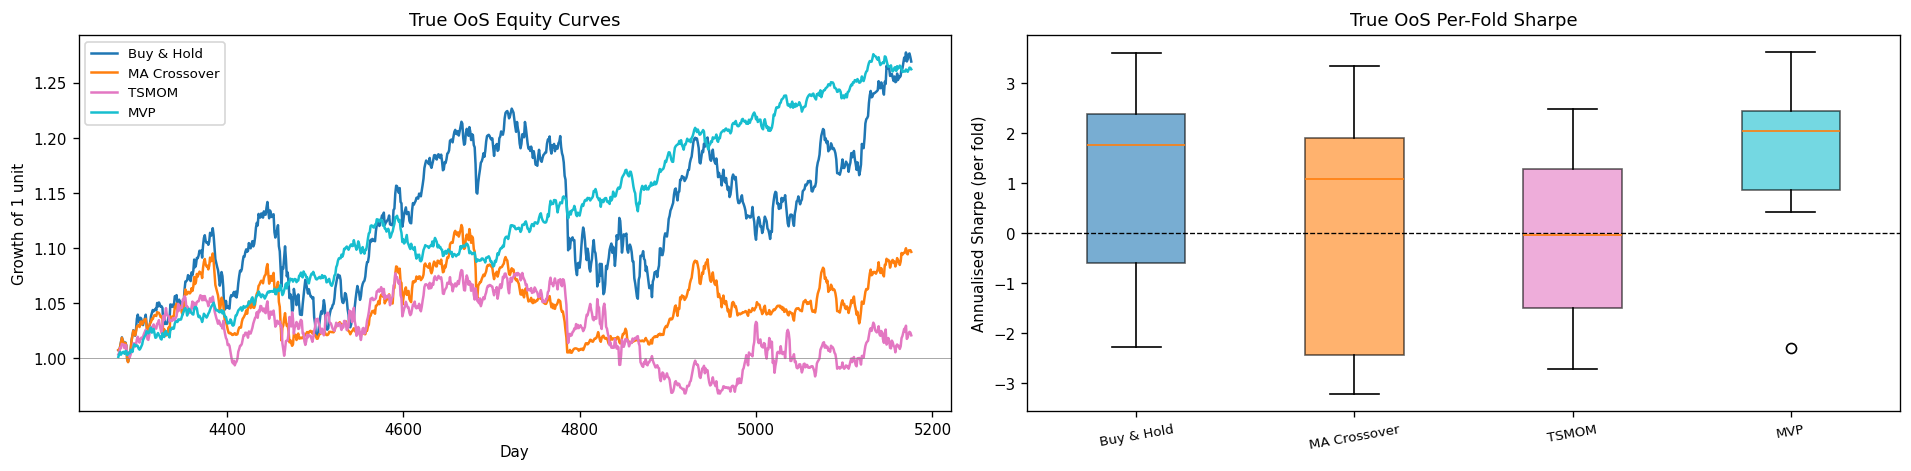

In [45]:
print('=== True OoS Performance ===')
roos_rows = []
for name, _ in roos_strats:
    roos_rows.append(backtest_metrics(ROOS[name]['rets'], label=name))

roos_tbl = pd.DataFrame(roos_rows).set_index('Strategy').round(4)
roos_tbl['Ann. Return']  = roos_tbl['Ann. Return'].map('{:+.2%}'.format)
roos_tbl['Ann. Vol']     = roos_tbl['Ann. Vol'].map('{:.2%}'.format)
roos_tbl['Max Drawdown'] = roos_tbl['Max Drawdown'].map('{:.2%}'.format)
roos_tbl['Sharpe']       = roos_tbl['Sharpe'].map('{:.3f}'.format)
display(roos_tbl)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
ax = axes[0]
for name, _ in roos_strats:
    cum = (1 + ROOS[name]['rets']).cumprod()
    ax.plot(cum.index, cum.values, lw=1.5, label=name, color=COLORS.get(name, 'gray'))
ax.axhline(1.0, color='gray', lw=0.4)
ax.set(xlabel='Day', ylabel='Growth of 1 unit', title='True OoS Equity Curves')
ax.legend(fontsize=8)

ax2 = axes[1]
all_fold = [ROOS[n]['fold_srs'] for n,_ in roos_strats]
bp = ax2.boxplot(all_fold, labels=[n for n,_ in roos_strats], patch_artist=True)
for patch, (name, _) in zip(bp['boxes'], roos_strats):
    patch.set_facecolor(COLORS.get(name, 'gray')); patch.set_alpha(0.6)
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.set(ylabel='Annualised Sharpe (per fold)', title='True OoS Per-Fold Sharpe')
ax2.tick_params(axis='x', labelsize=8, rotation=10)

plt.tight_layout()
plt.savefig('../Output/task4/real_oos.png', dpi=150)
plt.show()


## 9. Production Readiness Assessment

In [46]:
prod = pd.DataFrame([
    {'Strategy': 'Buy & Hold',    'Params': '0',                      'Grid': '—',               'Refit': 'Never',                        'Overfitting risk': 'None'},
    {'Strategy': 'MA Crossover',  'Params': '2/asset (14 total)',      'Grid': '12 combos/asset', 'Refit': f'Every {OOS_STEP} d (WF)',     'Overfitting risk': 'Low–moderate'},
    {'Strategy': 'Ch. Breakout',  'Params': '2/asset (14 total)',      'Grid': '9 combos/asset',  'Refit': f'Every {OOS_STEP} d (WF)',     'Overfitting risk': 'Low–moderate'},
    {'Strategy': 'Buy the Dip',   'Params': '3/asset (21 total)',      'Grid': '27 combos/asset', 'Refit': f'Every {OOS_STEP} d (WF)',     'Overfitting risk': 'Moderate'},
    {'Strategy': 'Pairs (L/S)',   'Params': '2/pair (4 total)',        'Grid': '4 combos/pair',   'Refit': f'Every {OOS_STEP} d (WF)',     'Overfitting risk': 'Low (no cointegration → short-term reversion only)'},
    {'Strategy': 'TSMOM',         'Params': '1/asset (7 total)',       'Grid': '4 combos/asset',  'Refit': f'Every {OOS_STEP} d (WF)',     'Overfitting risk': 'Low (vol scaling non-parametric)'},
    {'Strategy': 'Seasonal',      'Params': '1/asset (7 total)',       'Grid': '4 combos/asset',  'Refit': f'Every {OOS_STEP} d (WF)',     'Overfitting risk': 'Low (~2 trades/year; slow signal)'},
    {'Strategy': 'MVP',           'Params': '0 (no return forecast)',  'Grid': '—',               'Refit': f'Every {OOS_STEP} d (WF)',     'Overfitting risk': 'Low–moderate (cov estimation error)'},
]).set_index('Strategy')
print(prod.to_string())


                              Params             Grid             Refit                                    Overfitting risk
Strategy                                                                                                                   
Buy & Hold                         0                —             Never                                                None
MA Crossover      2/asset (14 total)  12 combos/asset  Every 100 d (WF)                                        Low–moderate
Ch. Breakout      2/asset (14 total)   9 combos/asset  Every 100 d (WF)                                        Low–moderate
Buy the Dip       3/asset (21 total)  27 combos/asset  Every 100 d (WF)                                            Moderate
Pairs (L/S)         2/pair (4 total)    4 combos/pair  Every 100 d (WF)  Low (no cointegration → short-term reversion only)
TSMOM              1/asset (7 total)   4 combos/asset  Every 100 d (WF)                    Low (vol scaling non-parametric)
Seasonal

---
## 10. Results and Discussion

The following section interprets the walk-forward evaluation results. All figures refer to the concatenated pseudo-OoS return series (IS = 500 days, step = 100 days, ~34 folds over the development pool).


### 10.1 Overall Performance Ranking

| Strategy | Sharpe | Ann. Return | Ann. Vol | Max Drawdown |
|---|---|---|---|---|
| MVP | **0.43** | +5.06 % | **4.95 %** | **−7.65 %** |
| MA Crossover | 0.33 | +5.19 % | 6.72 % | −15.05 % |
| TSMOM | 0.26 | +5.14 % | 8.33 % | −12.63 % |
| Buy the Dip | 0.19 | +4.29 % | 7.04 % | −17.01 % |
| Seasonal | 0.17 | +4.26 % | 7.59 % | −23.42 % |
| Buy & Hold | 0.06 | +3.67 % | 11.09 % | −37.55 % |
| Channel Breakout | −0.01 | +2.92 % | 5.61 % | −12.84 % |
| Pairs (L/S) | **−0.30** | +1.15 % | 5.99 % | −9.64 % |

Five of the eight strategies improve on Buy & Hold's Sharpe ratio. Only Channel Breakout and Pairs Trading fail to cover the risk-free rate on a risk-adjusted basis. The spread between the best (MVP, 0.43) and worst (Pairs, −0.30) is substantial, suggesting the choice of strategy matters more than parameter tuning within any single strategy.


### 10.2 The Case for Covariance-Driven Allocation

MVP is the clear winner — it achieves the highest Sharpe, the lowest realised volatility (4.95 % p.a.), and the smallest maximum drawdown (−7.65 %), all without making any forecast of expected returns.

The explanation lies in the asset universe. Task 1 identified two distinct volatility tiers: gurkor and water at ~6 % p.a. versus the remaining five assets at ~20–24 % p.a. An equal-weight portfolio allocates 1/7 of capital to each asset, but the high-vol group contributes roughly 90 % of total portfolio variance. MVP corrects this mechanically — the last IS window assigns approximately 62 % to gurkor and 19 % to water, concentrating over 80 % of the book in the low-vol pair. The consequence is a portfolio that earns a return broadly in line with the active strategies while running at less than half their volatility.

This result is a useful benchmark for any active strategy to clear: if a signal-based approach cannot improve on a covariance-only rebalancing rule, it is not adding information beyond what the risk structure already implies.


### 10.3 Signal-Based Strategies: What Works

**MA Crossover** is the strongest pure signal strategy (Sharpe 0.33). It earns a similar annualised return to TSMOM and MVP (+5.19 %) while keeping volatility lower than TSMOM (6.72 % vs 8.33 %). The flat-position mechanism — earning the risk-free rate when the trend signal is off — provides a meaningful drag reduction: the strategy is out of the market for a material fraction of time, which suppresses drawdowns relative to always-invested approaches like TSMOM.

**TSMOM** (Sharpe 0.26) confirms the positive autocorrelation and ARCH effects identified in Task 1. Volatility scaling disciplines position sizes so that high-vol regimes do not dominate drawdowns; the strategy's maximum drawdown (−12.63 %) is comparable to MA Crossover's despite being always invested long or short. Per-fold, TSMOM is positive in 56 % of folds — the highest hit-rate among signal-based strategies.

**Buy the Dip and Seasonal** both post positive but modest Sharpe ratios (~0.19 and 0.17). Buy the Dip's mean fold Sharpe (0.56) is actually the highest of any strategy on a per-fold basis, suggesting it performs well in the typical fold but suffers in tail-event folds. Seasonal's maximum drawdown (−23.42 %) is disproportionate to its Sharpe, indicating that when the seasonal extrapolation is wrong it can stay wrong for extended periods.


### 10.4 Signal-Based Strategies: What Does Not Work

**Channel Breakout** produces a Sharpe indistinguishable from zero (−0.01 overall; mean fold Sharpe −0.12, positive in only 44 % of folds). The Donchian breakout signal generates entries after a move has already occurred, and the price series in this dataset do not exhibit the persistent trending behaviour the strategy requires. It earns its quoted annualised return of +2.92 % almost entirely from flat-period risk-free income rather than from directional positions.

**Pairs Trading** is the weakest strategy outright (Sharpe −0.30, mean fold Sharpe −0.20). The result is consistent with Task 1's finding that no pair in the universe is cointegrated: the Engle-Granger test found p-values above 0.06 for every pair, and Johansen failed to identify any cointegrating vector. Without a long-run equilibrium pulling the spread back, the z-score strategy bets on short-term reversion that does not systematically materialise. The low volatility (5.99 % p.a.) and small drawdown (−9.64 %) reflect that the strategy spends much of its time flat, but the returns when invested are on balance negative.


### 10.5 Per-Fold Consistency

Examining the distribution of fold-level Sharpe ratios (each fold covers 100 OOS days) reveals how much of each strategy's aggregate performance can be trusted.

All strategies exhibit standard deviations of fold Sharpe between 1.6 and 2.3 — large relative to the mean in every case. A 100-day window is simply too short to distinguish skill from noise in any single fold. The key metric is therefore the **fraction of positive folds**:

| Strategy | % Positive Folds |
|---|---|
| MVP | 58 % |
| TSMOM | 56 % |
| Seasonal | 53 % |
| Buy the Dip | 51 % |
| MA Crossover | 49 % |
| Buy & Hold | 47 % |
| Channel Breakout | 44 % |
| Pairs (L/S) | 44 % |

Even the best strategies are positive in only slightly more than half of all folds. This is not unusual — 100-day Sharpe ratios are noisy — but it means that a practitioner evaluating any strategy over a six-month window would frequently observe negative performance by chance, even from the strategies that work in aggregate. The aggregate concatenated Sharpe ratio is therefore a more reliable guide than any single-period result.


### 10.6 Risk Characteristics

Maximum drawdown is the most operationally significant risk measure for a strategy that must be explained to stakeholders or operated under capital constraints.

Buy & Hold's −37.55 % drawdown is the worst in the set — the cost of full market exposure with no exit mechanism. Seasonal's −23.42 % is the worst among active strategies and stands out as an outlier relative to its Sharpe (0.17): the seasonal signal can be directionally wrong for extended stretches when the commodity cycles shift or the STL extrapolation diverges from realised prices.

MA Crossover (−15.05 %) and TSMOM (−12.63 %) strike a reasonable balance between return and drawdown. Both achieve returns around 5 % p.a. with drawdowns less than half that of Buy & Hold, which is the key practical advantage of having an exit signal at all — even an imperfect one.

MVP's −7.65 % drawdown stands alone. Its risk reduction is structural: the gurkor/water overweight means the portfolio is never exposed to a simultaneous adverse move across all seven assets at full weight. This makes MVP the most defensible choice under capital constraints or drawdown limits.


### 10.7 Summary

Three broad conclusions emerge from the walk-forward evaluation:

1. **Risk-based allocation dominates pure signal strategies.** MVP outperforms every signal-based approach on a risk-adjusted basis by exploiting the pronounced two-tier volatility structure of the asset universe. It requires no return forecast and is robust to parameter overfitting because it has none.

2. **Trend-following works; mean-reversion does not.** MA Crossover and TSMOM both deliver credible Sharpe ratios in the 0.26–0.33 range, consistent with the positive autocorrelation structure identified in Task 1. Pairs Trading and Channel Breakout — which rely on reversion and breakout dynamics that the data does not clearly support — fail to add value after accounting for the risk-free rate.

3. **Individual fold performance is uninformative.** The high variance of 100-day Sharpe ratios means no strategy can be judged reliable or unreliable from a single period. Evaluation must aggregate across many folds, and the bootstrap results should be read with the caveat that iid resampling understates the true uncertainty for strategies with serial position dependence.

A practical portfolio built from these results would likely combine MVP weights (for structural risk control) with a momentum overlay — either MA Crossover or TSMOM — to capture the directional signal while keeping drawdowns within an acceptable range.
